<a href="https://colab.research.google.com/github/Haile-12/Laza-tegaru/blob/develop/data_mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Importing necessary python libraries

---





In [73]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,precision_score, recall_score,f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from google.colab import drive
print('All Libraries are  imported successfully!')

All Libraries are  imported successfully!




---


2. importing the data set from google drive

---



In [74]:
drive.mount('/content/drive')
# Specify the path to your file
file_path = '/content/drive/My Drive/data.csv'
df = pd.read_csv(file_path)

# Display the first few rows of the DataFrame
print('Data imported from your Drive successfully!')
print('Data set before applying the labeled classfiers with shape of ' + str(df.shape))
print(df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data imported from your Drive successfully!
Data set before applying the labeled classfiers with shape of (8191, 9)
       book_id                                      edition_title  \
0  OL10099717M                 UC 2095 TWT Promo (Time Warp Trio)   
1  OL10100353M                             Descent of Man 11-copy   
2   OL1010530M                          Super, natural Christians   
3  OL10108502M  An Act to Amend the Chesapeake and Ohio Canal ...   
4  OL10108502M  An Act to Amend the Chesapeake and Ohio Canal ...   

                                          work_title  number_of_pages  \
0                                        Knucklehead             76.0   
1                              The road to Wellville              NaN   
2                              Metaphorical theology            207.0   
3               M4 Carbine M16A2 W/E Armorer's G



---


3.Defining target variable rating category


---





In [78]:
def classify_rating(rating):
    if rating <= 2:
        return 'low'
    elif rating <= 3:
        return 'medium'
    else:
        return 'high'

df['rating_category'] = df['rating'].apply(classify_rating)
print('Data set after applying the labeled classfiers with shape of '+ str(df.shape))
print(df.head())

Data set after applying the labeled classfiers with shape of (8191, 10)
       book_id                                      edition_title  \
0  OL10099717M                 UC 2095 TWT Promo (Time Warp Trio)   
1  OL10100353M                             Descent of Man 11-copy   
2   OL1010530M                          Super, natural Christians   
3  OL10108502M  An Act to Amend the Chesapeake and Ohio Canal ...   
4  OL10108502M  An Act to Amend the Chesapeake and Ohio Canal ...   

                                          work_title  number_of_pages  \
0                                        Knucklehead             76.0   
1                              The road to Wellville              NaN   
2                              Metaphorical theology            207.0   
3               M4 Carbine M16A2 W/E Armorer's Guide              NaN   
4  The Constitution of the United States and rela...              NaN   

   publish_year  physical_format           author_name  \
0           NaN 



---


4. Preprocess the data

---



In [80]:
# Preprocess the data with imputation
categorical_features = ['physical_format', 'author_name', 'subjects']
numerical_features = ['publish_year', 'number_of_pages']
target = 'rating_category'

X = df[categorical_features + numerical_features]
y = df[target]

# Create pipelines for numerical and categorical features
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')), # Impute missing numerical values with the mean
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine pipelines using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline, numerical_features),
        ('cat', categorical_pipeline, categorical_features)
    ])

print(' Data Preprocesssed succssefully!')

 Data Preprocesssed succssefully!




---


5. Splitting the data in to train and test data


---



In [81]:

#splitting the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



---


6. Defining the models


---



/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Logistic Regression Accuracy: 0.78
Classification Report:
              precision    recall  f1-score   support

        high       0.82      0.90      0.86      1128
         low       0.63      0.36      0.46       187
      medium       0.66      0.58      0.62       324

    accuracy                           0.78      1639
   macro avg       0.70      0.62      0.65      1639
weighted avg       0.77      0.78      0.77      1639



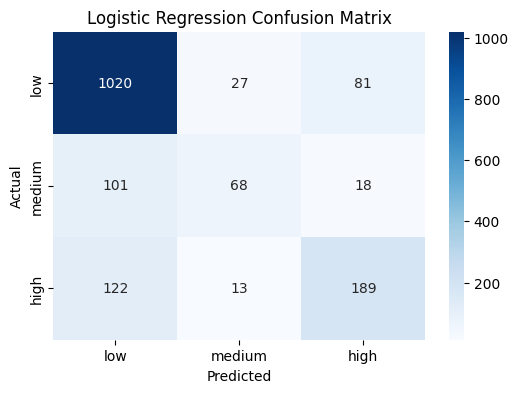


Random Forest Accuracy: 0.69
Classification Report:
              precision    recall  f1-score   support

        high       0.79      0.82      0.80      1128
         low       0.35      0.31      0.33       187
      medium       0.49      0.46      0.48       324

    accuracy                           0.69      1639
   macro avg       0.54      0.53      0.54      1639
weighted avg       0.68      0.69      0.68      1639



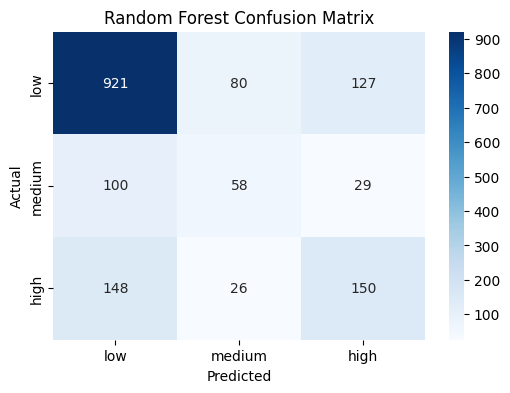


Decision Tree Accuracy: 0.70
Classification Report:
              precision    recall  f1-score   support

        high       0.77      0.85      0.81      1128
         low       0.38      0.24      0.29       187
      medium       0.55      0.46      0.50       324

    accuracy                           0.70      1639
   macro avg       0.57      0.52      0.53      1639
weighted avg       0.68      0.70      0.69      1639



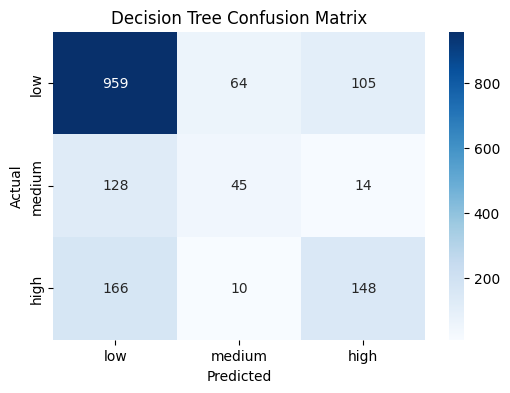


KNN Accuracy: 0.73
Classification Report:
              precision    recall  f1-score   support

        high       0.78      0.89      0.83      1128
         low       0.49      0.28      0.35       187
      medium       0.60      0.45      0.51       324

    accuracy                           0.73      1639
   macro avg       0.62      0.54      0.57      1639
weighted avg       0.71      0.73      0.71      1639



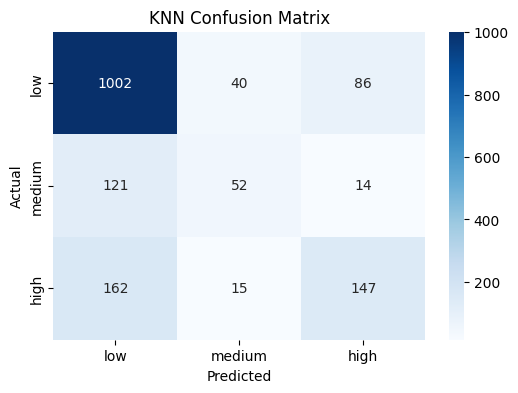


SVM Accuracy: 0.77
Classification Report:
              precision    recall  f1-score   support

        high       0.83      0.87      0.85      1128
         low       0.57      0.45      0.50       187
      medium       0.64      0.61      0.62       324

    accuracy                           0.77      1639
   macro avg       0.68      0.64      0.66      1639
weighted avg       0.76      0.77      0.77      1639



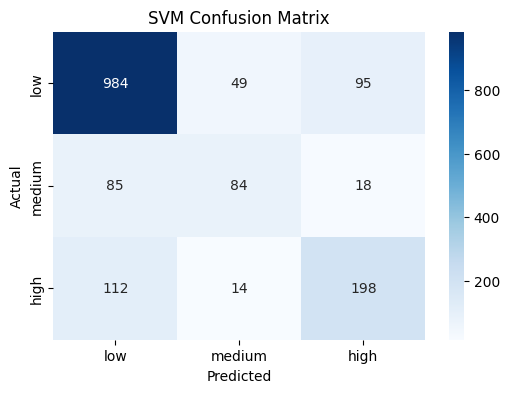


Naive Bayes Accuracy: 0.48
Classification Report:
              precision    recall  f1-score   support

        high       0.70      0.50      0.58      1128
         low       0.50      0.30      0.37       187
      medium       0.22      0.49      0.31       324

    accuracy                           0.48      1639
   macro avg       0.47      0.43      0.42      1639
weighted avg       0.58      0.48      0.50      1639



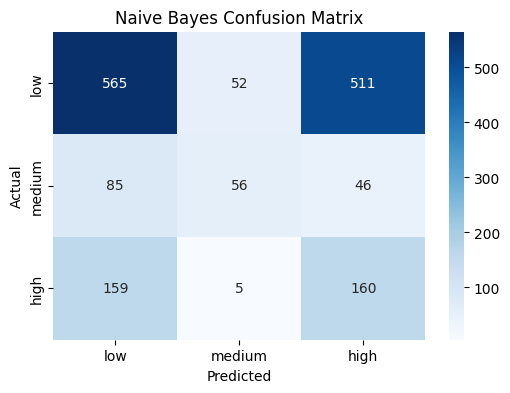

In [84]:
classifiers = {
    "Logistic Regression": LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=9),
    "SVM": LinearSVC(max_iter=10000),
    "Naive Bayes": MultinomialNB()
}

results = {}

for name, model in classifiers.items():
    # Create a separate pipeline for Naive Bayes without scaling
    if name == "Naive Bayes":
        nb_pipeline = Pipeline(steps=[
            ('preprocessor', ColumnTransformer(
                transformers=[
                    ('num', SimpleImputer(strategy='mean'), numerical_features), # Only impute, no scaling
                    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
                ])),
            ('classifier', model)
        ])
        pipeline = nb_pipeline  # Use the separate pipeline for Naive Bayes
    else:
        pipeline = Pipeline(steps=[
            ('preprocessor', preprocessor),  # Use the original pipeline for other models
            ('classifier', model)
        ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')  # Calculate weighted average precision
    recall = recall_score(y_test, y_pred, average='weighted')  # Calculate weighted average recall
    f1 = f1_score(y_test, y_pred, average='weighted')  # Calculate weighted average F1-score

    results[name] = {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1 Score': f1}  # Store all metrics

    print(f"\n{name} Accuracy: {accuracy:.2f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['low', 'medium', 'high'],
                yticklabels=['low', 'medium', 'high'])
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Convert results to DataFrame
results_df = pd.DataFrame.from_dict(results, orient='index')



---


7. Evualation of the Models


---



In [85]:
print("\nModel Comparison:")
print(results_df.sort_values(by='Accuracy', ascending=False))


Model Comparison:
                     Accuracy  Precision    Recall  F1 Score
Logistic Regression  0.779134   0.766319  0.779134  0.766843
SVM                  0.772422   0.764475  0.772422  0.767253
KNN                  0.732764   0.709750  0.732764  0.713715
Decision Tree        0.702868   0.679463  0.702868  0.686960
Random Forest        0.688835   0.679473  0.688835  0.683738
Naive Bayes          0.476510   0.581306  0.476510  0.504856




---
7. 📊 Final model comparsion


---





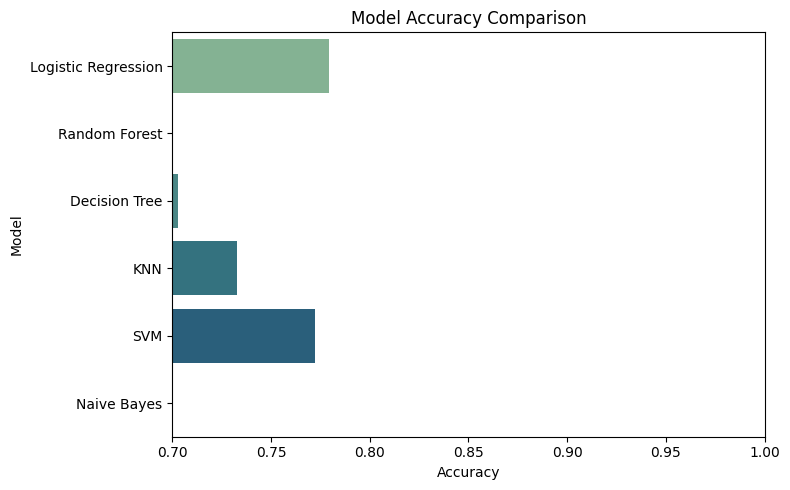

In [86]:
plt.figure(figsize=(8, 5))
# Reset the index to make 'Model' a column
results_df = results_df.reset_index().rename(columns={'index': 'Model'})
sns.barplot(data=results_df, x="Accuracy", y="Model", hue="Model", palette="crest", legend=False)
plt.title("Model Accuracy Comparison")
plt.xlim(0.7, 1.0)
plt.tight_layout()
plt.show()